# 29 - CNN Transfer Learning Front-Only 4-Class

**Dataset:** Front-only 4-Class
**3 Skenario:** B1 (Baseline), B2 (Class Weights), B3 (Weights + Augmentasi) (Transfer Learning)

In [1]:
import sys, os, json
import numpy as np
import torch
import torch.nn as nn
from pathlib import Path
from torch.utils.data import DataLoader
from collections import Counter

PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from training.models import EmotionCNNTransfer
from training.utils import (
    EmotionImageDataset, EmotionLandmarkDataset, EmotionMultimodalDataset,
    get_class_weights, train_model, full_evaluation,
    plot_training_history, plot_confusion_matrix, plot_per_class_f1
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)})")

Device: cuda
GPU: Tesla T4)


In [2]:
DATASET_DIR = PROJECT_ROOT / "data" / "dataset_frontonly_4class"
DATASET_AUG_DIR = PROJECT_ROOT / "data" / "dataset_frontonly_4class_augmented"
OUTPUT_DIR = PROJECT_ROOT / "models" / "frontonly" / "4class_tl"
os.makedirs(OUTPUT_DIR, exist_ok=True)

BATCH_SIZE = 32
EPOCHS = 50
LR = 0.00005
PATIENCE = 15
NUM_CLASSES = 4
EMOTIONS = ["neutral", "happy", "sad", "negative"]

print(f"Dataset: {DATASET_DIR}")
print(f"Output: {OUTPUT_DIR}")

Dataset: /home/bs000716/MOTHER-TANK/TRAIN/data/dataset_frontonly_4class
Output: /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly/4class_tl


In [3]:
print("Loading image data...")
def load_dataloaders(dataset_dir, batch_size=32):
    train_ds = EmotionImageDataset(dataset_dir / "X_train_images.npy", dataset_dir / "y_train.npy")
    val_ds = EmotionImageDataset(dataset_dir / "X_val_images.npy", dataset_dir / "y_val.npy")
    test_ds = EmotionImageDataset(dataset_dir / "X_test_images.npy", dataset_dir / "y_test.npy")
    train_l = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_l = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_l = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    y = np.load(dataset_dir / "y_train.npy")
    counts = Counter(y.tolist())
    print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")
    for i, e in enumerate(EMOTIONS): print(f"  {e:>10s}: {counts.get(i, 0)}")
    return train_l, val_l, test_l

train_loader, val_loader, test_loader = load_dataloaders(DATASET_DIR, BATCH_SIZE)

Loading image data...


Train: 5348 | Val: 707 | Test: 1036
     neutral: 4192
       happy: 660
         sad: 382
    negative: 114


## Skenario B1: Baseline

Model parameters: 11,309,380

Training CNN_TL B1 - Baseline (Front-Only)...
 Epoch  Train Loss  Train Acc   Val Loss   Val Acc   Val F1         LR
---------------------------------------------------------------------------


     1      0.9080     0.6932     0.6062    0.9137   0.3789   0.000050  (18.5s)


     2      0.5210     0.8588     0.3748    0.9406   0.3456   0.000050  (18.1s)


     3      0.3796     0.8871     0.3448    0.9420   0.3788   0.000050  (18.2s)


     4      0.3062     0.9065     0.3583    0.9236   0.3286   0.000050  (18.2s)


...

    12      0.0235     0.9991     0.4195    0.9038   0.3090   0.000025  (18.1s)


    13      0.0199     0.9991     0.4979    0.8586   0.2740   0.000025  (18.1s)


    14      0.0173     1.0000     0.3941    0.9052   0.2936   0.000025  (18.1s)


    15      0.0162     0.9996     0.3784    0.9081   0.3096   0.000025  (18.0s)


    16      0.0153     0.9991     0.5415    0.8190   0.2621   0.000025  (18.1s)

Early stopping at epoch 16. Best epoch: 1 (val_f1=0.3789)

Best: epoch 1, val_acc=0.9137, val_f1=0.3789
Model saved: /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly/4class_tl/cnn_tl_b1.pth


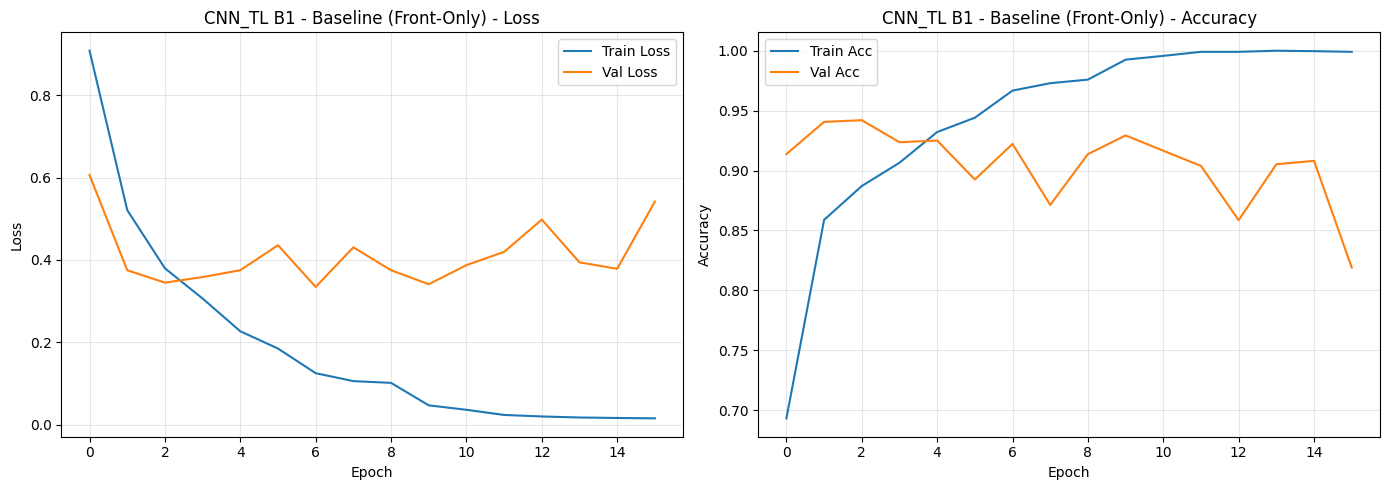

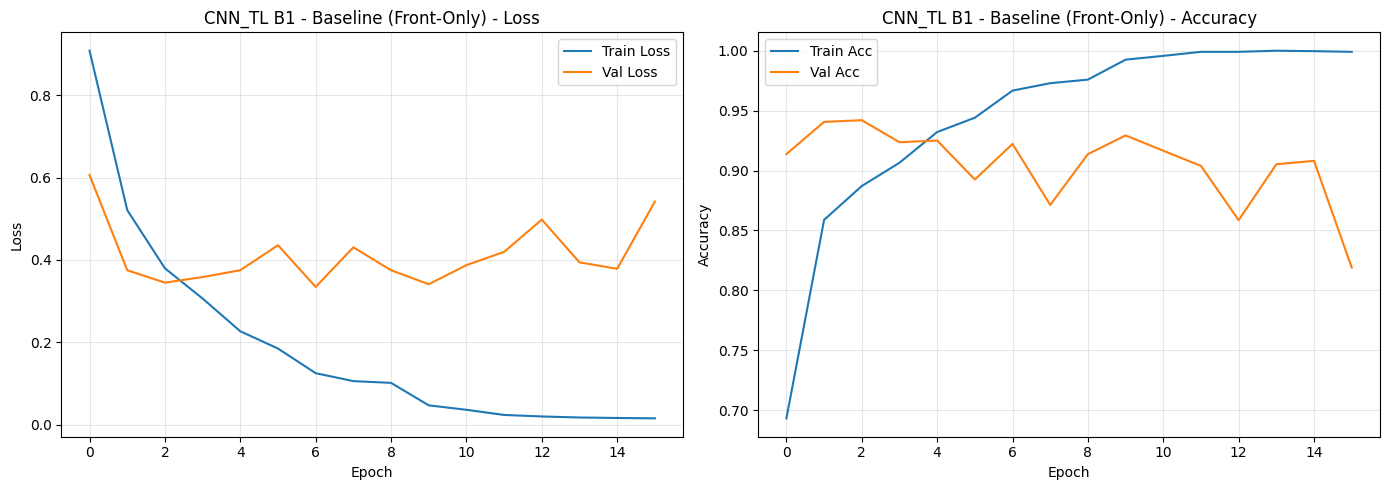

In [4]:
# B1: Baseline
criterion = nn.CrossEntropyLoss()

model = EmotionCNNTransfer(num_classes=NUM_CLASSES).to(device)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=8, min_lr=1e-7)

print("\nTraining CNN_TL B1 - Baseline (Front-Only)...")
history, best_epoch = train_model(
    model, train_loader, val_loader, criterion, optimizer, scheduler,
    device, model_type="cnn", epochs=EPOCHS, patience=PATIENCE,
    save_path=str(OUTPUT_DIR / "cnn_tl_b1.pth"))

plot_training_history(history, "CNN_TL B1 - Baseline (Front-Only)")

EVALUASI B1 - BASELINE


Test Loss: 0.5730
Test Accuracy: 0.9237
Test Macro F1: 0.2743
Test Weighted F1: 0.9136

Classification Report:
              precision    recall  f1-score   support

     neutral       0.95      0.97      0.96       981
       happy       0.09      0.10      0.10        10
         sad       0.05      0.03      0.04        29
    negative       0.00      0.00      0.00        16

    accuracy                           0.92      1036
   macro avg       0.27      0.28      0.27      1036
weighted avg       0.90      0.92      0.91      1036



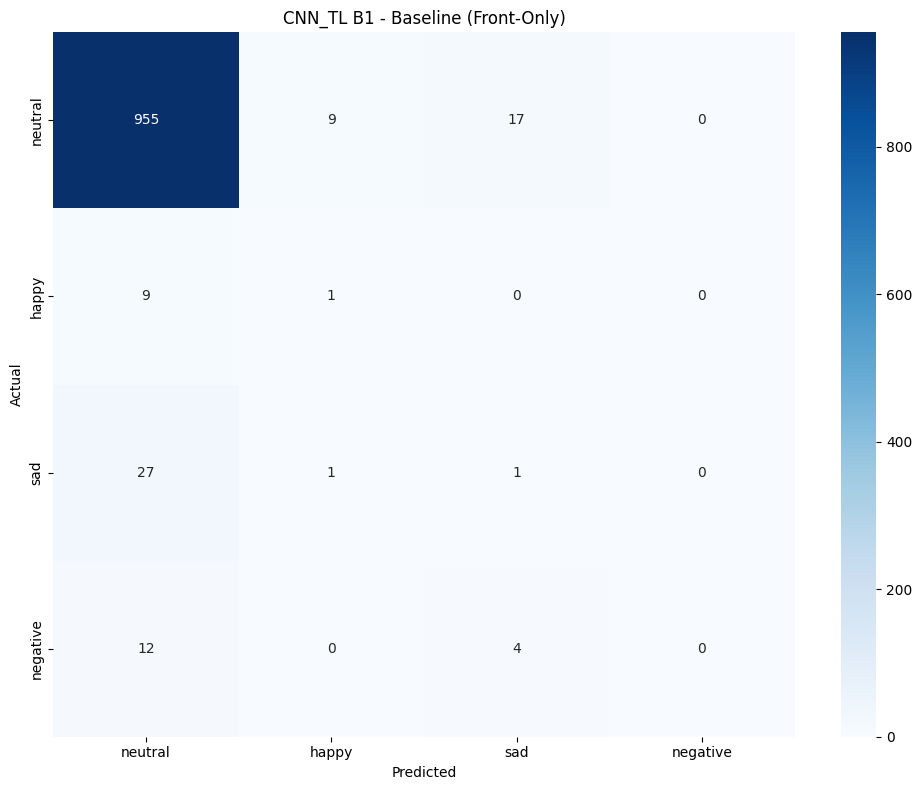

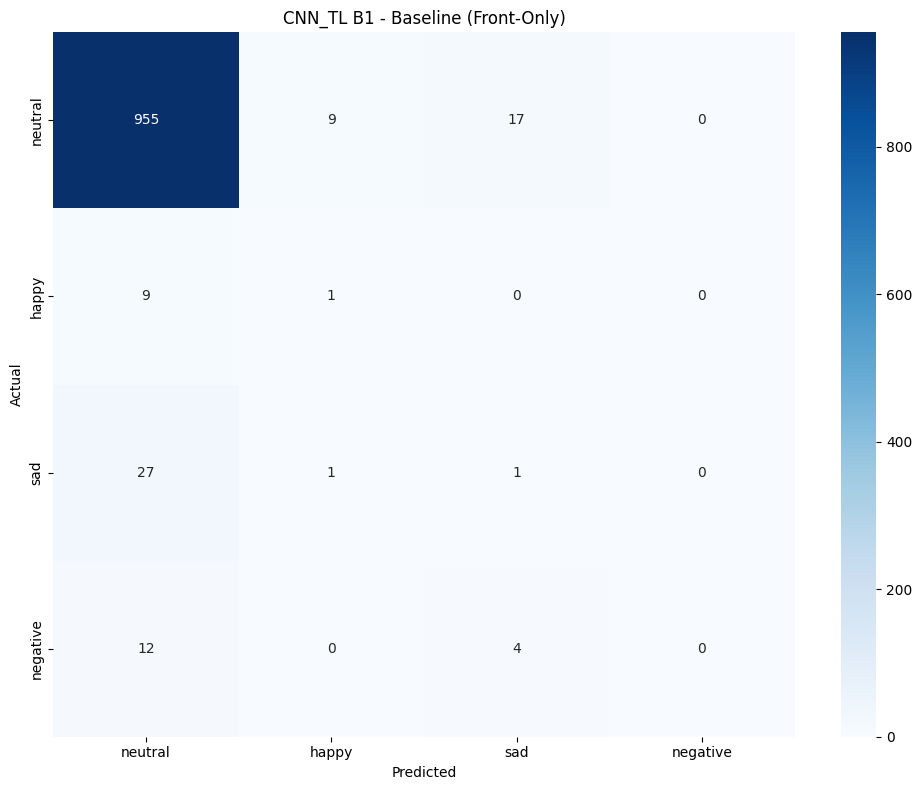

In [5]:
# Evaluate B1
model.load_state_dict(torch.load(OUTPUT_DIR / "cnn_tl_b1.pth", map_location=device, weights_only=True))
print("=" * 60)
print("EVALUASI B1 - BASELINE")
print("=" * 60)
results_b1 = full_evaluation(model, test_loader, criterion, device, "cnn", EMOTIONS)
plot_confusion_matrix(results_b1["confusion_matrix"], "CNN_TL B1 - Baseline (Front-Only)", emotions=EMOTIONS)

## Skenario B2: Class Weights

Class weights: None


Model parameters: 11,309,380

Training CNN_TL B2 - Class Weights (Front-Only)...
 Epoch  Train Loss  Train Acc   Val Loss   Val Acc   Val F1         LR
---------------------------------------------------------------------------


     1      0.8323     0.7416     0.6044    0.9321   0.4200   0.000050  (18.0s)


     2      0.4984     0.8596     0.4161    0.9321   0.3225   0.000050  (18.1s)


     3      0.3799     0.8844     0.4086    0.8883   0.3330   0.000050  (18.2s)


...

    15      0.0151     0.9993     0.3319    0.8925   0.3457   0.000025  (18.1s)


    16      0.0151     0.9987     0.3132    0.9010   0.3298   0.000025  (18.1s)


    17      0.0130     0.9993     0.3155    0.9024   0.3203   0.000025  (18.1s)


    18      0.0104     0.9996     0.2927    0.9052   0.3476   0.000025  (18.1s)


    19      0.0087     1.0000     0.2940    0.9066   0.3603   0.000025  (18.0s)

Early stopping at epoch 19. Best epoch: 4 (val_f1=0.4383)

Best: epoch 4, val_acc=0.9349, val_f1=0.4383
Model saved: /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly/4class_tl/cnn_tl_b2.pth


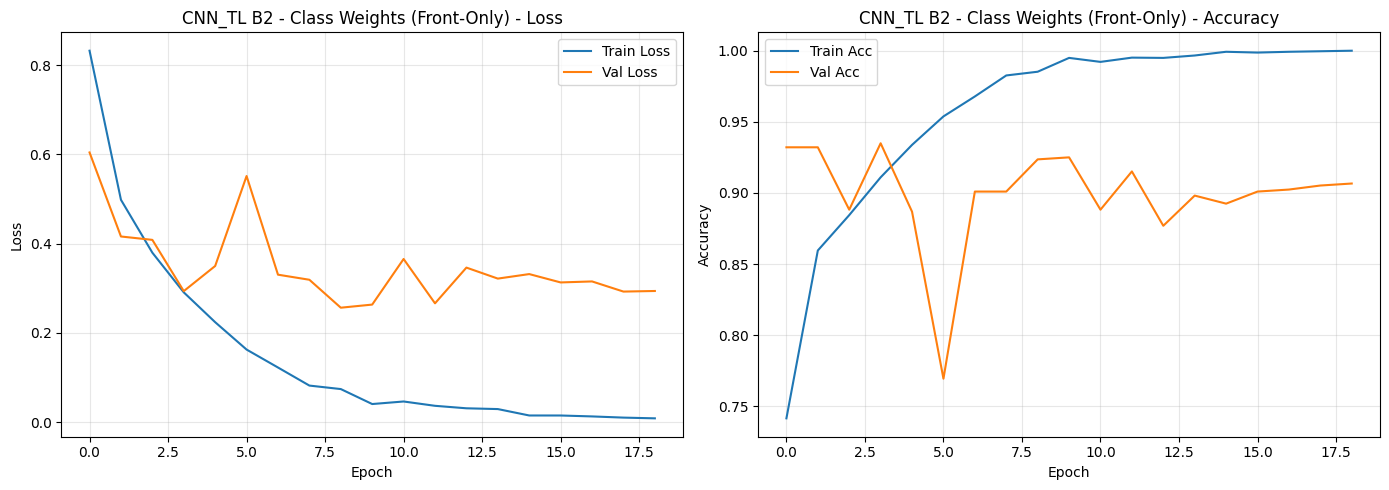

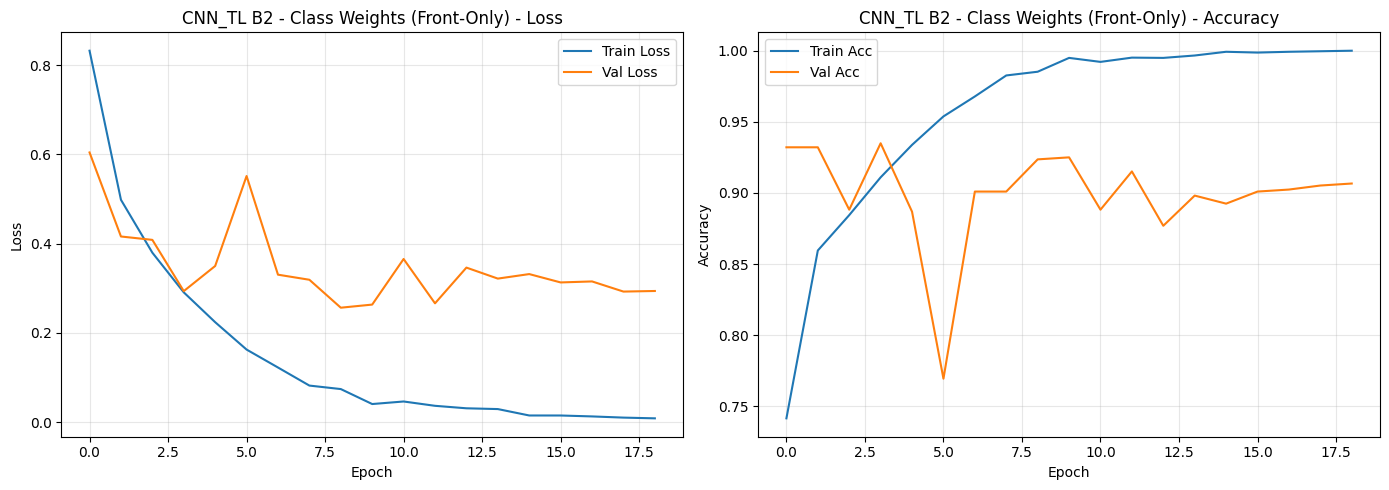

In [6]:
# B2: Class Weights
weights = get_class_weights(DATASET_DIR, device)
print(f"Class weights: {weights}")
criterion = nn.CrossEntropyLoss(weight=weights)

model = EmotionCNNTransfer(num_classes=NUM_CLASSES).to(device)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=8, min_lr=1e-7)

print("\nTraining CNN_TL B2 - Class Weights (Front-Only)...")
history, best_epoch = train_model(
    model, train_loader, val_loader, criterion, optimizer, scheduler,
    device, model_type="cnn", epochs=EPOCHS, patience=PATIENCE,
    save_path=str(OUTPUT_DIR / "cnn_tl_b2.pth"))

plot_training_history(history, "CNN_TL B2 - Class Weights (Front-Only)")

EVALUASI B2 - CLASS WEIGHTS


Test Loss: 0.2481
Test Accuracy: 0.9247
Test Macro F1: 0.2425
Test Weighted F1: 0.9186

Classification Report:
              precision    recall  f1-score   support

     neutral       0.96      0.98      0.97       981
       happy       0.00      0.00      0.00        10
         sad       0.00      0.00      0.00        29
    negative       0.00      0.00      0.00        16

    accuracy                           0.92      1036
   macro avg       0.24      0.24      0.24      1036
weighted avg       0.91      0.92      0.92      1036



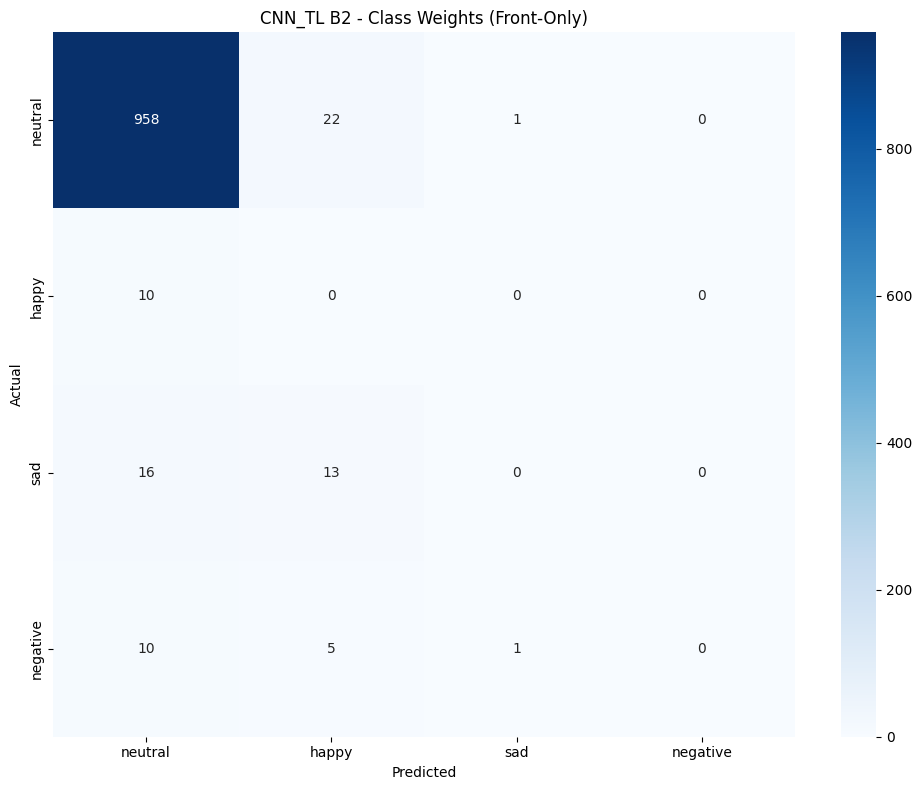

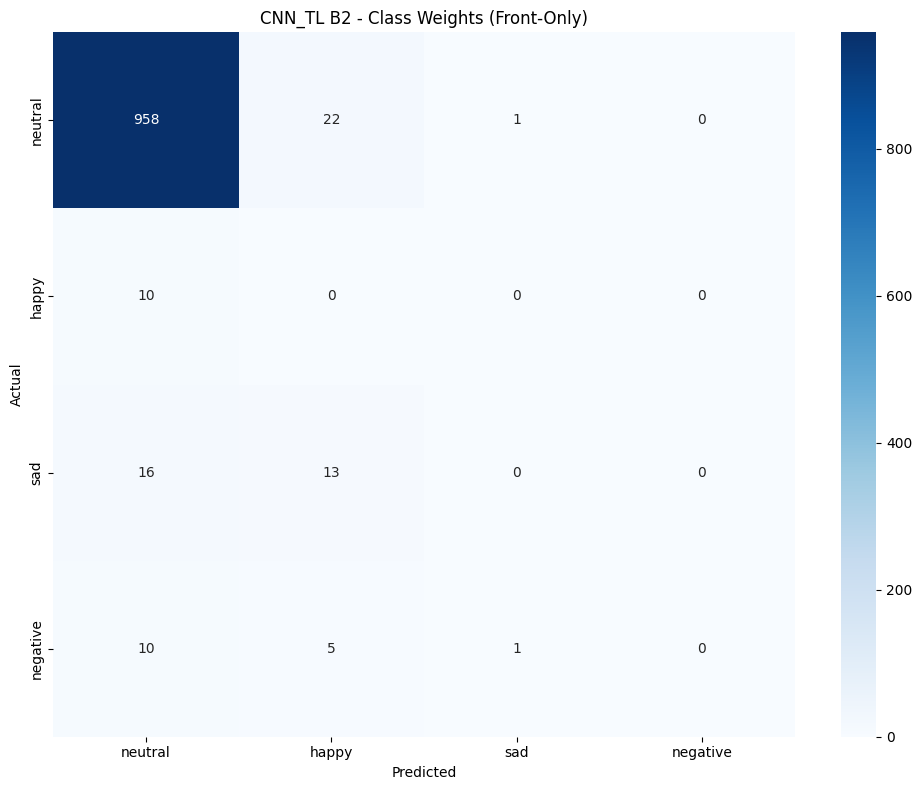

In [7]:
# Evaluate B2
model.load_state_dict(torch.load(OUTPUT_DIR / "cnn_tl_b2.pth", map_location=device, weights_only=True))
print("=" * 60)
print("EVALUASI B2 - CLASS WEIGHTS")
print("=" * 60)
results_b2 = full_evaluation(model, test_loader, criterion, device, "cnn", EMOTIONS)
plot_confusion_matrix(results_b2["confusion_matrix"], "CNN_TL B2 - Class Weights (Front-Only)", emotions=EMOTIONS)

## Skenario B3: Class Weights + Augmentasi

Train: 5834 | Val: 707 | Test: 1036
     neutral: 4192
       happy: 660
         sad: 382
    negative: 600
Augmented class weights: None


Model parameters: 11,309,380

Training CNN_TL B3 - Weights + Augmentasi (Front-Only)...
 Epoch  Train Loss  Train Acc   Val Loss   Val Acc   Val F1         LR
---------------------------------------------------------------------------


     1      0.9584     0.6865     0.6362    0.8911   0.3462   0.000050  (20.5s)


     2      0.5021     0.8574     0.3695    0.9321   0.3709   0.000050  (20.9s)


     3      0.3500     0.8970     0.3010    0.9335   0.3524   0.000050  (20.7s)


...

    39      0.0039     0.9997     0.3101    0.9364   0.3722   0.000013  (20.6s)


    40      0.0026     1.0000     0.2869    0.9335   0.3609   0.000013  (20.5s)


    41      0.0020     1.0000     0.3000    0.9392   0.3815   0.000013  (20.6s)


    42      0.0019     1.0000     0.3124    0.9264   0.3601   0.000013  (20.7s)


    43      0.0027     0.9998     0.2971    0.9293   0.3603   0.000013  (20.7s)

Early stopping at epoch 43. Best epoch: 28 (val_f1=0.3982)

Best: epoch 28, val_acc=0.9349, val_f1=0.3982
Model saved: /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly/4class_tl/cnn_tl_b3.pth


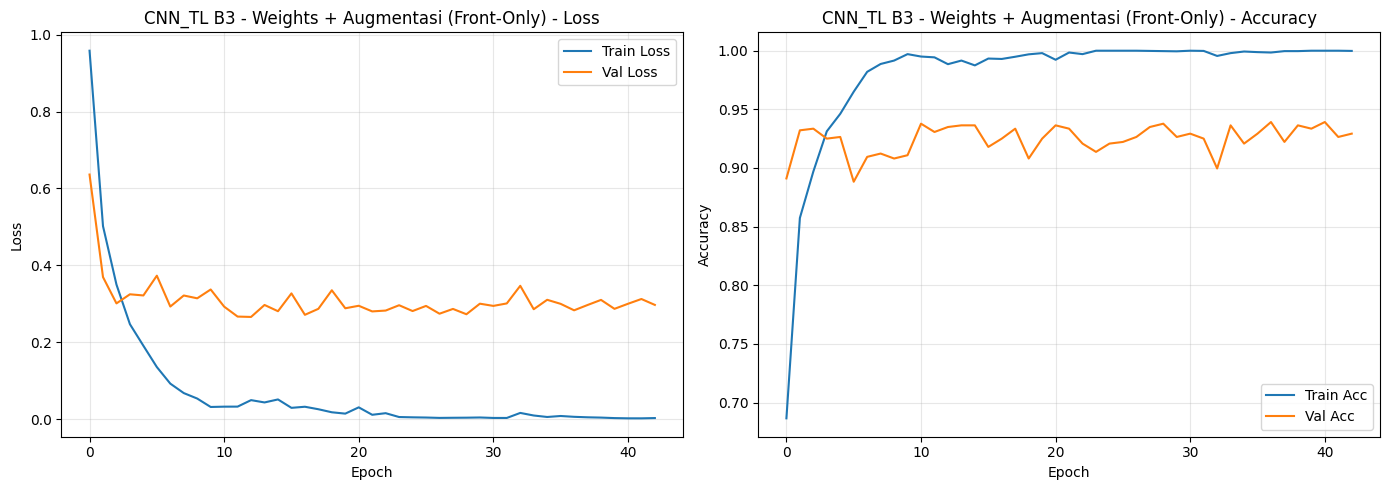

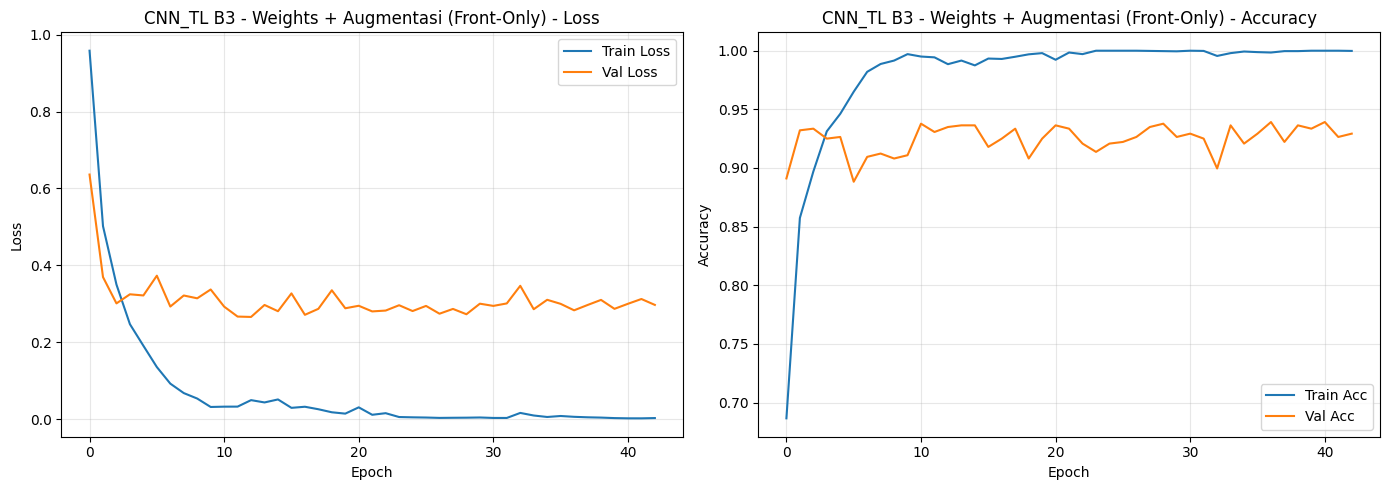

In [8]:
# B3: Weights + Augmentasi
train_loader_aug, _, _ = load_dataloaders(DATASET_AUG_DIR, BATCH_SIZE)
weights_aug = get_class_weights(DATASET_AUG_DIR, device)
print(f"Augmented class weights: {weights_aug}")
criterion = nn.CrossEntropyLoss(weight=weights_aug)

model = EmotionCNNTransfer(num_classes=NUM_CLASSES).to(device)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=8, min_lr=1e-7)

print("\nTraining CNN_TL B3 - Weights + Augmentasi (Front-Only)...")
history, best_epoch = train_model(
    model, train_loader_aug, val_loader, criterion, optimizer, scheduler,
    device, model_type="cnn", epochs=EPOCHS, patience=PATIENCE,
    save_path=str(OUTPUT_DIR / "cnn_tl_b3.pth"))

plot_training_history(history, "CNN_TL B3 - Weights + Augmentasi (Front-Only)")

EVALUASI B3 - WEIGHTS + AUGMENTASI


Test Loss: 0.2842
Test Accuracy: 0.9237
Test Macro F1: 0.2564
Test Weighted F1: 0.9138

Classification Report:
              precision    recall  f1-score   support

     neutral       0.95      0.97      0.96       981
       happy       0.00      0.00      0.00        10
         sad       0.33      0.03      0.06        29
    negative       0.00      0.00      0.00        16

    accuracy                           0.92      1036
   macro avg       0.32      0.25      0.26      1036
weighted avg       0.91      0.92      0.91      1036



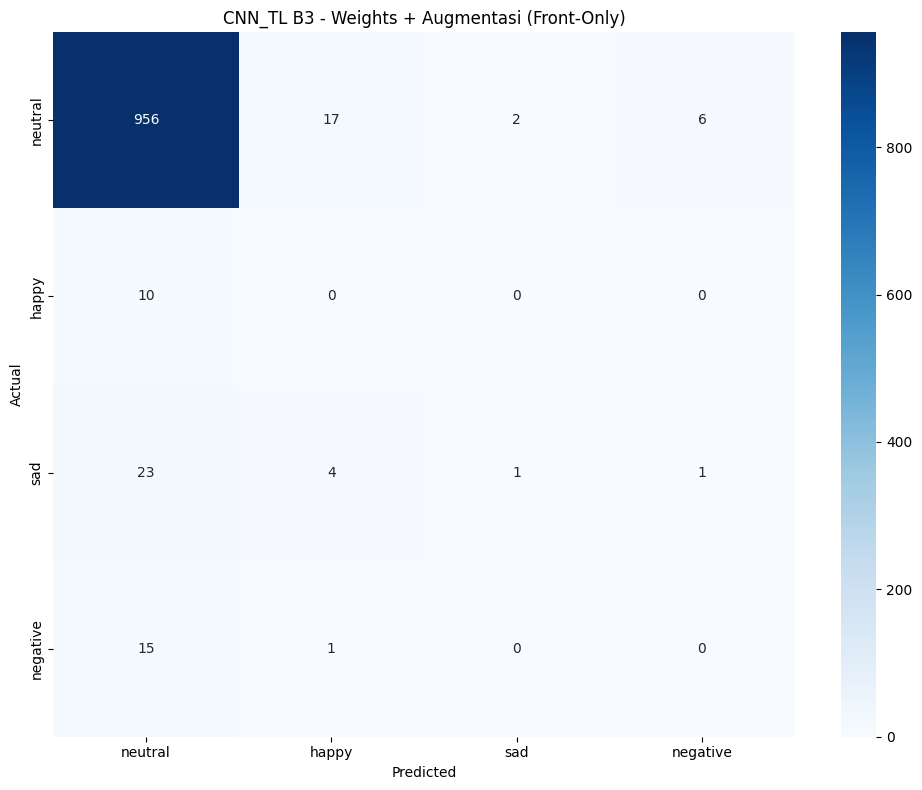

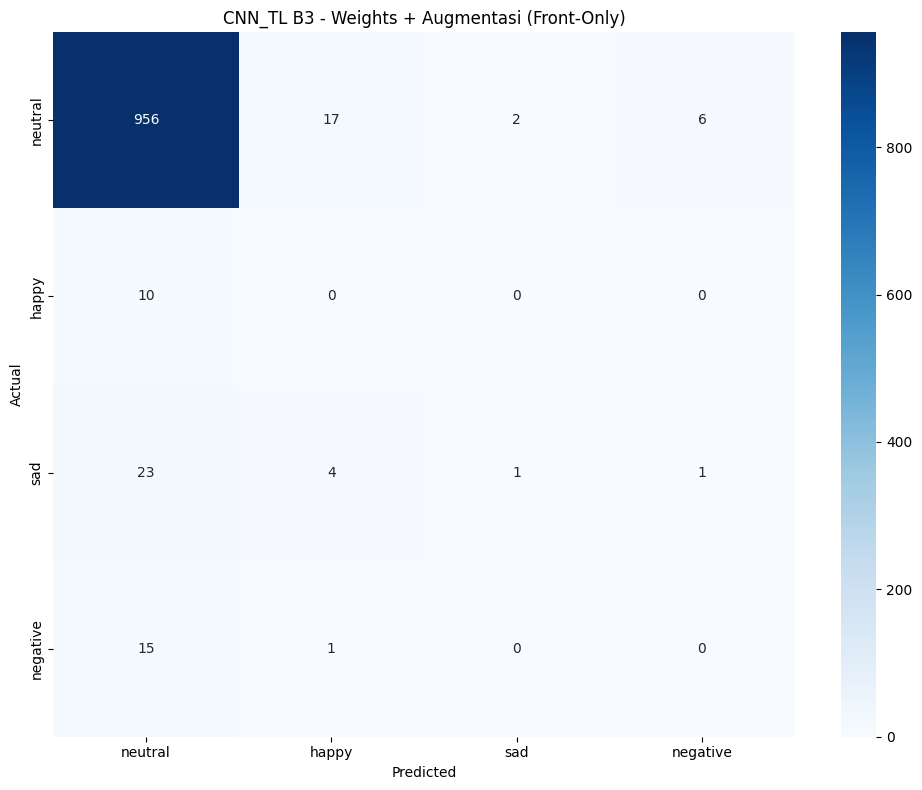

In [9]:
# Evaluate B3
model.load_state_dict(torch.load(OUTPUT_DIR / "cnn_tl_b3.pth", map_location=device, weights_only=True))
print("=" * 60)
print("EVALUASI B3 - WEIGHTS + AUGMENTASI")
print("=" * 60)
results_b3 = full_evaluation(model, test_loader, criterion, device, "cnn", EMOTIONS)
plot_confusion_matrix(results_b3["confusion_matrix"], "CNN_TL B3 - Weights + Augmentasi (Front-Only)", emotions=EMOTIONS)

## Perbandingan 3 Skenario

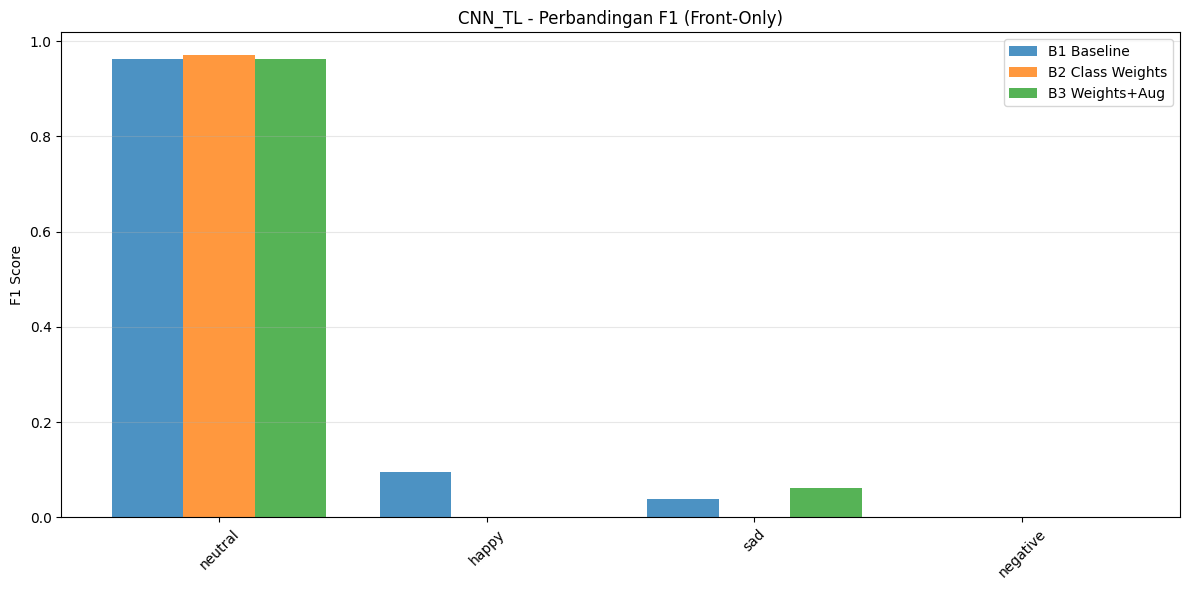

RINGKASAN CNN_TL FRONT-ONLY
Skenario                    Accuracy   Macro F1  Weighted F1
----------------------------------------------------------------------
B1 Baseline                   0.9237     0.2743       0.9136
B2 Class Weights              0.9247     0.2425       0.9186
B3 Weights+Aug                0.9237     0.2564       0.9138

Saved to /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly/4class_tl/cnn_tl_results.json


In [10]:
# Perbandingan
all_results = {
    "B1 Baseline": results_b1,
    "B2 Class Weights": results_b2,
    "B3 Weights+Aug": results_b3,
}
plot_per_class_f1(all_results, "CNN_TL - Perbandingan F1 (Front-Only)", emotions=EMOTIONS)

print("=" * 70)
print("RINGKASAN CNN_TL FRONT-ONLY")
print("=" * 70)
print(f"{'Skenario':<25} {'Accuracy':>10} {'Macro F1':>10} {'Weighted F1':>12}")
print("-" * 70)
for name, r in all_results.items():
    print(f"{name:<25} {r['test_accuracy']:>10.4f} {r['test_macro_f1']:>10.4f} {r['test_weighted_f1']:>12.4f}")

results_save = {}
for name, r in all_results.items():
    results_save[name] = {
        "accuracy": float(r["test_accuracy"]),
        "macro_f1": float(r["test_macro_f1"]),
        "weighted_f1": float(r["test_weighted_f1"]),
    }
with open(OUTPUT_DIR / "cnn_tl_results.json", "w") as f:
    json.dump(results_save, f, indent=2)
print(f"\nSaved to {OUTPUT_DIR / 'cnn_tl_results.json'}")